# Cliff Walking with TD methods

In this notebook we compare two Temporal-Difference (TD) control algorithms:
- **SARSA** (on-policy)
- **Q-learning** (off-policy)

We train both agents in `CliffWalking-v1`, compare learning curves, and save short policy rollouts as GIF files.

In [7]:
import gymnasium as gym
from pathlib import Path
from RLCodeBase import ReinforcementLearningBase, plot_learning_curves_with_confidence_intervals
import numpy as np
from IPython.display import display, Image


### SARSA agent

`SARSA` updates Q-values with the action that the current policy will actually take next.
This makes it **on-policy** and often more conservative in risky environments.

Update rule:

$Q(s,a) \leftarrow Q(s,a) + \alpha\left[r + \gamma Q(s',a') - Q(s,a)\right]$




In [ ]:
class SARSA(ReinforcementLearningBase):
  def __init__(self, env, gamma, alpha, epsilon, min_epsilon, epsilon_decay):
    super().__init__(env, gamma, epsilon, min_epsilon, epsilon_decay)
    self.alpha=alpha

  def train(self, num_episodes):
    for episode in range(num_episodes):
      state, _ = env.reset()
      done = False
      total_reward=0;
      success = False
      steps=0
      action = self.epsilon_greedy_policy(state)
      while not done:
        next_state, reward, done, truncation, _ = env.step(action)
        done=done or truncation
        total_reward+=reward
        next_action = self.epsilon_greedy_policy(next_state)
        self.update_Q(state, action, reward, next_state, next_action)
        state = next_state
        action=next_action
      self.episode_returns.append(total_reward)
      self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)
      if (episode + 1) % 100 == 0:
          print(f"> Episode: {episode + 1}, Epsilon: {self.epsilon:.4f}, Return: {total_reward:.4f}")

  def update_Q(self, state, action, reward, next_state, next_action):
    self.Q[state][action] += self.alpha*(reward + self.gamma * self.Q[next_state][next_action]-self.Q[state][action])

# Q-learning agent

`Q_learning` updates toward the greedy best next action, independent of the current behavior policy.
This is an **off-policy** method and typically learns an optimal greedy policy faster, although exploration can still visit risky states during training.

Update rule:

$Q(s,a) \leftarrow Q(s,a) + \alpha\left[r + \gamma \max_{a'}Q(s',a') - Q(s,a)\right]$

In [ ]:
class Q_learning(ReinforcementLearningBase):
  def __init__(self, env, gamma, alpha, epsilon, min_epsilon, epsilon_decay):
    super().__init__(env, gamma, epsilon, min_epsilon, epsilon_decay)
    self.alpha=alpha

  def train(self, num_episodes):
    for episode in range(num_episodes):
      state, _ = self.env.reset()
      done = False
      total_reward=0;
      success = False
      steps=0
      while not done:
        action = self.epsilon_greedy_policy(state)
        next_state, reward, done, truncation, _ = self.env.step(action)
        done=done or truncation
        total_reward+=reward
        self.update_Q(state, action, reward, next_state)
        state = next_state

      self.episode_returns.append(total_reward)
      self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)
      if (episode + 1) % 100 == 0:
          print(f"> Episode: {episode + 1}, Epsilon: {self.epsilon:.4f}, Return: {total_reward:.4f}")

  def update_Q(self, state, action, reward, next_state):
    best_next_action = np.argmax(self.Q[next_state])
    self.Q[state][action] += self.alpha*(reward + self.gamma *  self.Q[next_state][best_next_action]-self.Q[state][action])

# Experiment setup

We define hyperparameters and run multiple independent trainings (`N_RUNS`) to reduce variance.
The final plot shows average behavior with confidence intervals.

In [ ]:
# Hyperparameters
NUM_EPISODES = 600  # Total number of episodes
GAMMA = 0.99  # Discount factor
EPSILON = 0.1  # Exploration rate
MIN_EPSILON = 0.01  # Minimum exploration rate
EPSILON_DECAY = 1  # Decay rate for exploration
ALPHA = 0.3  # Learning rate
TIME_LIMIT=1000

returns={"SARSA":[],
         "Q_learning":[]}
N_RUNS=100

# Initialize the CliffWalking environment
env = gym.make('CliffWalking-v1',is_slippery=False,render_mode="rgb_array")
video_dir = Path("videos")
video_dir.mkdir(parents=True, exist_ok=True)
frames=[]

# Train both agents across multiple runs
for _ in range(N_RUNS):
    sarsa=SARSA(env, GAMMA, ALPHA, EPSILON, MIN_EPSILON, EPSILON_DECAY)
    sarsa.train(NUM_EPISODES)
    returns["SARSA"].append(sarsa.episode_returns)
    q_learning=Q_learning(env, GAMMA, ALPHA, EPSILON, MIN_EPSILON, EPSILON_DECAY)
    q_learning.train(NUM_EPISODES)
    returns["Q_learning"].append(q_learning.episode_returns)



# Learning curves

This figure compares SARSA and Q-learning over episodes.
The shaded area is a confidence interval across runs.

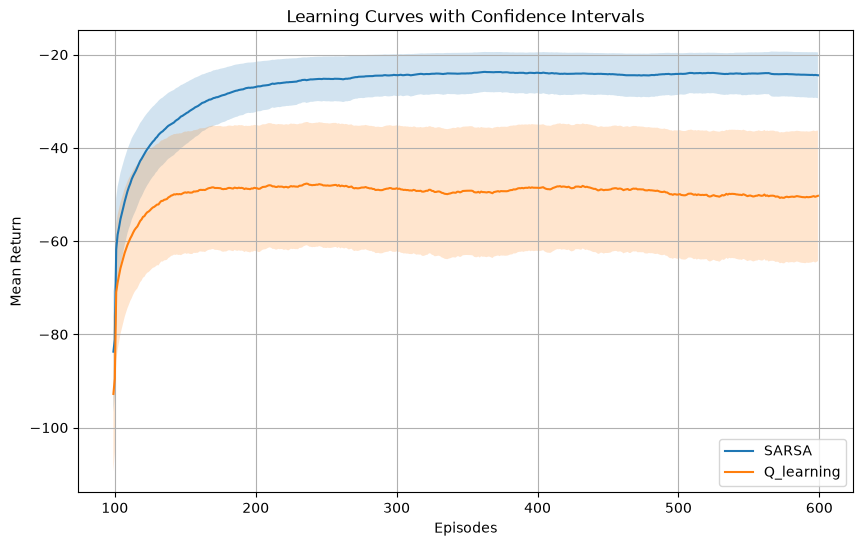

In [11]:
plot_learning_curves_with_confidence_intervals(returns)

# Policy evaluation and GIF rendering

We evaluate each trained policy, save a short rollout as GIF, and display it in the notebook.
GIF is used for broad compatibility in classroom environments.


In [ ]:
# Evaluate the policy
sarsa_video_path = video_dir / "cliffWalking_sarsa.gif"
avg_reward= sarsa.evaluate_policy(save_video=True, video_dir=str(sarsa_video_path))

q_learning_video_path = video_dir / "cliffWalking_q_learning.gif"
avg_reward = q_learning.evaluate_policy(save_video=True, video_dir=str(q_learning_video_path))

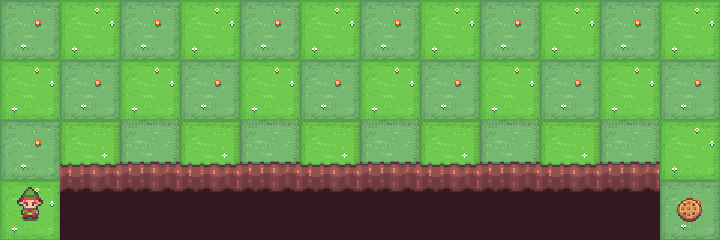

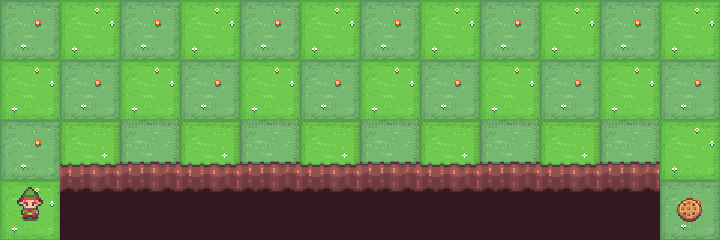

In [13]:
display(Image(filename=str(sarsa_video_path)))
display(Image(filename=str(q_learning_video_path)))